### Setup

In [1]:
import numba
import requests
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
from collections import namedtuple

CondensedTree = namedtuple(
    "CondensedTree", ["parent", "child", "lambda_val", "child_size"]
)

In [2]:
data = np.load(
    BytesIO(
        requests.get(
            "https://github.com/scikit-learn-contrib/hdbscan/blob/master/notebooks/clusterable_data.npy?raw=true"
        ).content
    )
)

In [4]:
from fast_hdbscan.hdbscan import compute_minimum_spanning_tree

min_samples = 10
min_cluster_size = min_samples
mst, _, _ = compute_minimum_spanning_tree(data, min_samples=min_samples)
mst = mst[np.argsort(mst.T[2])]

## Linkage

Change linkage compute code. 

- Make the hierarchy a named tuple to avoid type mismatches later on! 
- Ensure unweighted counts are available even with weighted samples!
- Keep performance similar or make it better!


In [5]:
def equal_linkage(l1, l2):
    print(f"Equal parents: {np.all(l1[:, 0].astype(np.int64) == l2.parent)}")
    print(f"Equal children: {np.all(l1[:, 1].astype(np.int64) == l2.child)}")
    print(f"Equal counts: {np.all(l1[:, 3].astype(np.int64) == l2.count)}")

In [6]:
from fast_hdbscan.hdbscan import mst_to_linkage_tree as current_mst_to_linkage_tree

In [7]:
linkage = current_mst_to_linkage_tree(mst)

In [8]:
%%timeit
current_mst_to_linkage_tree(mst)

29.8 µs ± 33.1 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### New version

In [9]:
LinkageHierarchy = namedtuple("LinkageMergeData", ["parent", "child", "count", "size"])
LinkageMergeData = namedtuple("LinkageMergeData", ["parent", "count", "size"])


@numba.njit(locals=dict(left=numba.int64, right=numba.int64))
def mst_to_linkage_tree(sorted_mst, sample_weights=None):
    num_edges = sorted_mst.shape[0]
    num_points = num_edges + 1
    linkage = allocate_linkage(num_edges)
    state = create_linkage_merge_data(num_points, sample_weights)

    for i, (left, right) in enumerate(sorted_mst[:, :2]):
        left = linkage_merge_find(state, left)
        right = linkage_merge_find(state, right)
        store_link(linkage, state, i, left, right)
        linkage_merge_union(linkage, state, num_points, i, left, right)

    return linkage


@numba.njit(inline="always")
def allocate_linkage(size):
    return LinkageHierarchy(
        parent=np.empty(size, dtype=np.int64),
        child=np.empty(size, dtype=np.int64),
        count=np.empty(size, dtype=np.int64),
        size=np.empty(size, dtype=np.float32),
    )


@numba.njit(inline="always")
def create_linkage_merge_data(base_size, sample_weights=None):
    full_size = 2 * base_size - 1
    state = LinkageMergeData(
        parent=np.full(full_size, -1, dtype=np.int64),
        count=np.empty(full_size, dtype=np.int64),
        size=np.empty(full_size, dtype=np.float32),
    )
    state.count[:base_size] = 1
    if sample_weights is not None:
        state.size[:base_size] = sample_weights
    else:
        state.size[:base_size] = 1.0
    return state


@numba.njit(inline="always")
def linkage_merge_find(linkage_merge, node):
    relabel = node
    while linkage_merge.parent[node] != -1 and linkage_merge.parent[node] != node:
        node = linkage_merge.parent[node]
    linkage_merge.parent[node] = node

    # label up to the root
    while linkage_merge.parent[relabel] != node:
        next_relabel = linkage_merge.parent[relabel]
        linkage_merge.parent[relabel] = node
        relabel = next_relabel

    return node


@numba.njit(inline="always")
def linkage_merge_union(linkage, state, num_points, i, left, right):
    next = i + num_points
    state.count[next] = linkage.count[i]
    state.size[next] = linkage.size[i]
    state.parent[left] = next
    state.parent[right] = next


@numba.njit(inline="always")
def store_link(linkage, state, i, left, right):
    linkage.parent[i] = max(left, right)
    linkage.child[i] = min(left, right)
    linkage.count[i] = state.count[left] + state.count[right]
    linkage.size[i] = state.size[left] + state.size[right]

In [10]:
l2 = mst_to_linkage_tree(mst)
equal_linkage(linkage, l2)

Equal parents: True
Equal children: True
Equal counts: True


In [12]:
%%timeit
mst_to_linkage_tree(mst)

31.1 µs ± 206 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Condensed Tree

Equality for condensed trees. Child order does not matter as long as their
density and parent does not change. Overall sorted density order should be
maintained.

In [13]:
def equal_trees(ct1, ct2):
    # Parent-child relationships
    g_ct1 = {pt: set() for pt in range(data.shape[0], 2 * linkage.shape[0] + 1)}
    for pt, cd in zip(ct1.parent, ct1.child):
        g_ct1[pt].add(cd)

    g_ct2 = {pt: set() for pt in range(data.shape[0], 2 * linkage.shape[0] + 1)}
    for pt, cd in zip(ct2.parent, ct2.child):
        g_ct2[pt].add(cd)

    # Child-density relationships
    l_ct1 = {cd: lv for cd, lv in zip(ct1.child, ct1.lambda_val)}
    l_ct2 = {cd: lv for cd, lv in zip(ct2.child, ct2.lambda_val)}

    print(f"Equal parent-child: {g_ct1 == g_ct2}")
    print(f"Equal child-density: {l_ct1 == l_ct2}")
    print(f"Same parents: {np.all(ct1.parent == ct2.parent)}")
    print(f"Same lambda values: {np.all(ct1.lambda_val == ct2.lambda_val)}")
    print(f"Same child sizes: {np.all(ct1.child_size == ct2.child_size)}")

Current version

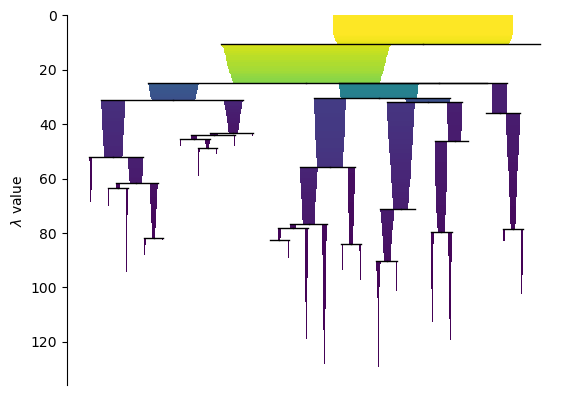

In [14]:
from fast_hdbscan.cluster_trees import condense_tree as current_condense_tree
from fast_hdbscan.hdbscan import to_numpy_rec_array
from hdbscan.plots import CondensedTree as PlotTree


current_ct = current_condense_tree(linkage, min_cluster_size=min_cluster_size)
PlotTree(to_numpy_rec_array(current_ct), np.zeros(data.shape[0])).plot(
    colorbar=False, leaf_separation=0.1
)
plt.show()

In [15]:
%%timeit 
current_condense_tree(linkage, min_cluster_size=10)

60.9 µs ± 522 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


### Improved version

- Avoid the bread-first traversal. Instead track where points in eliminated
branches should end up in the output.
- Avoid type conflicts
- One big function is 8x faster than splitting it into multiple functions :(

In [ ]:
@numba.njit(
    fastmath=True,
    error_model="numpy",
    locals={"left": numba.int64, "right": numba.int64},
)
def condense_tree(hierarchy, distances, min_cluster_size=10, max_cluster_size=np.inf, sample_weights=None):
    # Indexing variables, root represents the last row in the hierarchy
    num_points = hierarchy.parent.shape[0] + 1
    root = 2 * hierarchy.parent.shape[0]

    # Output arrays (shrink to fit after filling)
    parents = np.empty(root, dtype=np.int64)
    children = np.empty(root, dtype=np.int64)
    lambdas = np.empty(root, dtype=np.float32)
    sizes = np.empty(root, dtype=np.float32)

    # tracks the new parent ID for hierarchy rows
    parent_of = np.empty(root - num_points + 1, dtype=np.int64)
    parent_of[root - num_points] = num_points

    # tracks the output index to put points from eliminated branches (per branch parent)
    pending_idx = np.empty(root - num_points + 1, dtype=np.int64)
    pending_lambda = np.empty(root - num_points + 1, dtype=np.float32)

    # support weighted samples
    if sample_weights is None:
        sample_weights = np.ones(num_points, dtype=np.float32)

    # Iterate through the hierarchy in reverse order
    idx = 0
    next_label = num_points + 1
    for node in range(root, num_points - 1, -1):
        # Extract the row
        node_idx = node - num_points
        parent_node = parent_of[node_idx]
        left = hierarchy.parent[node_idx]
        right = hierarchy.child[node_idx]
        node_size = hierarchy.size[node_idx]
        node_dist = distances[node_idx]

        # Extract child sizes
        is_pt_left = left < num_points
        is_pt_right = right < num_points
        left_count = hierarchy.count[left - num_points] if not is_pt_left else 1
        right_count = hierarchy.count[right - num_points] if not is_pt_right else 1
        left_size = hierarchy.size[left - num_points] if not is_pt_left else sample_weights[left]
        right_size = hierarchy.size[right - num_points] if not is_pt_right else sample_weights[right]

        # Determine where to store potential points and update the relevant indices
        if node_size >= min_cluster_size:
            out_idx = idx
            lambda_value = 1.0 / node_dist
            # fmt: off
            idx += (
                (left_size < min_cluster_size) * left_count + 
                (right_size < min_cluster_size) * right_count
            )
            # fmt: on
        else:
            out_idx = pending_idx[node_idx]
            lambda_value = pending_lambda[node_idx]

        # Store row or update parent depending on if left is a point
        if is_pt_left:
            parents[out_idx] = parent_node
            children[out_idx] = left
            lambdas[out_idx] = lambda_value
            sizes[out_idx] = sample_weights[left]
            out_idx += 1
        else:
            parent_of[left - num_points] = parent_node
            if left_size < min_cluster_size:
                pending_idx[left - num_points] = out_idx
                pending_lambda[left - num_points] = lambda_value
                out_idx += left_count

        # Store row or update parent depending on if right is a point
        if is_pt_right:
            parents[out_idx] = parent_node
            children[out_idx] = right
            lambdas[out_idx] = lambda_value
            sizes[out_idx] = sample_weights[right]
        else:
            parent_of[right - num_points] = parent_node
            if right_size < min_cluster_size:
                pending_idx[right - num_points] = out_idx
                pending_lambda[right - num_points] = lambda_value

        # If both clusters are too large, skip this merge
        if left_size > max_cluster_size and right_size > max_cluster_size:
            continue

        # If both sides are large enough, store this merge
        if left_size >= min_cluster_size and right_size >= min_cluster_size:
            parent_of[left - num_points] = next_label
            parents[idx] = parent_node
            children[idx] = next_label
            lambdas[idx] = lambda_value
            sizes[idx] = left_size
            next_label += 1
            idx += 1

            parent_of[right - num_points] = next_label
            parents[idx] = parent_node
            children[idx] = next_label
            lambdas[idx] = lambda_value
            sizes[idx] = right_size
            next_label += 1
            idx += 1

    return CondensedTree(parents[:idx], children[:idx], lambdas[:idx], sizes[:idx])

Equal parent-child: True
Equal child-density: True
Same parents: True
Same lambda values: True
Same child sizes: True


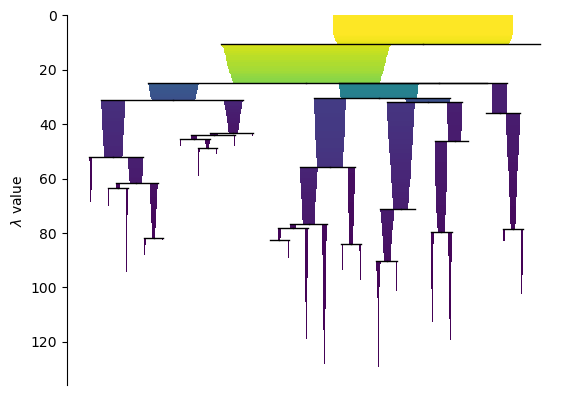

In [18]:
improved_ct = condense_tree(l2, mst[:, 2], min_cluster_size=min_cluster_size)
equal_trees(current_ct, improved_ct)
PlotTree(to_numpy_rec_array(improved_ct), np.zeros(data.shape[0])).plot(
    colorbar=False, leaf_separation=0.1
)
plt.show()

In [19]:
%%timeit 
condense_tree(l2, mst[:, 2], min_cluster_size=min_cluster_size)

12.1 µs ± 93.8 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


### Split into functions

Numba inlining does not offset the cost of splitting the code into functions. 

https://stackoverflow.com/questions/67213549/how-to-use-numba-optimally-accross-multiple-functions

In [ ]:
CondenseState = namedtuple(
    "CondenseState",
    [
        "parent_of",
        "pending_idx",
        "pending_lambda",
        "sample_weights",
        "counters",
        "min_cluster_size",
        "max_cluster_size",
        "num_points",
    ],
)


@numba.njit(locals=dict(num_points=numba.int64, root=numba.int64))
def condense_tree_split(
    hierarchy,
    distances,
    min_cluster_size=10,
    max_cluster_size=np.inf,
    sample_weights=None,
):
    # Indexing variables, root represents the last row in the hierarchy
    root = 2 * hierarchy.parent.shape[0]
    num_points = hierarchy.parent.shape[0] + 1
    tree = allocate_condensed_tree(root)
    state = create_state(
        min_cluster_size, max_cluster_size, root, num_points, sample_weights
    )

    process_hierarchy(hierarchy, distances, tree, state, root)

    idx = state.counters[0]
    return CondensedTree(
        tree.parent[:idx],
        tree.child[:idx],
        tree.lambda_val[:idx],
        tree.child_size[:idx],
    )


@numba.njit(inline="always")
def allocate_condensed_tree(size):
    return CondensedTree(
        parent=np.empty(size, dtype=np.int64),
        child=np.empty(size, dtype=np.int64),
        lambda_val=np.empty(size, dtype=np.float32),
        child_size=np.empty(size, dtype=np.float32),
    )


@numba.njit(inline="always")
def create_state(min_cluster_size, max_cluster_size, root, num_points, sample_weights):
    state = CondenseState(
        # Propagates parent ID
        parent_of=np.empty(root - num_points + 1, dtype=np.int64),
        # Track output index for points from eliminated branches
        pending_idx=np.empty(root - num_points + 1, dtype=np.int64),
        # Track lambda values for points from eliminated branches
        pending_lambda=np.empty(root - num_points + 1, dtype=np.float32),
        # Weighted samples default
        sample_weights=(
            np.ones(num_points, dtype=np.float32)
            if sample_weights is None
            else sample_weights
        ),
        # Mutable counters [idx, next_label]
        counters=np.array([0, num_points + 1], dtype=np.int64),
        # Constant parameters
        min_cluster_size=min_cluster_size,
        max_cluster_size=max_cluster_size,
        num_points=num_points,
    )
    state.parent_of[root - num_points] = num_points
    return state


@numba.njit(inline="always")
def process_hierarchy(hierarchy, distances, tree, state, root):
    for node in range(root, state.num_points - 1, -1):
        # Extract row information
        node_idx = node - state.num_points
        node_size = hierarchy.size[node_idx]
        node_dist = distances[node_idx]
        parent = state.parent_of[node_idx]
        left = hierarchy.parent[node_idx]
        right = hierarchy.child[node_idx]
        left_idx = left - state.num_points
        right_idx = right - state.num_points
        left_count = hierarchy.count[left_idx] if left_idx >= 0 else 1
        right_count = hierarchy.count[right_idx] if right_idx >= 0 else 1
        left_size = (
            hierarchy.size[left_idx] if left_idx >= 0 else state.sample_weights[left]
        )
        right_size = (
            hierarchy.size[right_idx] if right_idx >= 0 else state.sample_weights[right]
        )

        # Store or track where upcoming points should be stored
        out_idx, density = update_output_index(
            state,
            node_idx,
            node_dist,
            node_size,
            left_count,
            right_count,
            left_size,
            right_size,
        )
        out_idx = store_or_delay_side(
            tree, state, out_idx, parent, density, left, left_count, left_size
        )
        store_or_delay_side(
            tree, state, out_idx, parent, density, right, right_count, right_size
        )

        # Store cluster merges
        if left_size > state.max_cluster_size and right_size > state.max_cluster_size:
            return
        if left_size >= state.min_cluster_size and right_size >= state.min_cluster_size:
            write_merge(
                tree, state, parent, density, left_idx, left_size, right_idx, right_size
            )


@numba.njit(inline="always", fastmath=True)
def update_output_index(
    state,
    node_idx,
    node_dist,
    node_size,
    left_count,
    right_count,
    left_size,
    right_size,
):
    if node_size >= state.min_cluster_size:
        out_idx = state.counters[0]  # idx
        density = 1.0 / node_dist
        # fmt: off
        state.counters[0] += (
            (left_size < state.min_cluster_size) * left_count + 
            (right_size < state.min_cluster_size) * right_count
        )
        # fmt: on
    else:
        out_idx = state.pending_idx[node_idx]
        density = state.pending_lambda[node_idx]
    return out_idx, density


@numba.njit(inline="always")
def store_or_delay_side(
    tree, state, out_idx, parent, density, child, child_count, child_size
):
    if child < state.num_points:
        # Store the point in the output tree
        out_idx = write_row(tree, out_idx, parent, child, density, child_size)
    else:
        child_idx = np.int64(child - state.num_points)
        state.parent_of[child_idx] = parent
        if child_size < state.min_cluster_size:
            state.pending_idx[child_idx] = out_idx
            state.pending_lambda[child_idx] = density
            out_idx += child_count
    return out_idx


@numba.njit(inline="always")
def write_merge(
    tree, state, parent, density, left_idx, left_size, right_idx, right_size
):
    state.parent_of[left_idx] = state.counters[1]
    state.counters[0] = write_row(
        tree, state.counters[0], parent, state.counters[1], density, left_size
    )
    state.counters[1] += 1

    state.parent_of[right_idx] = state.counters[1]
    state.counters[0] = write_row(
        tree, state.counters[0], parent, state.counters[1], density, right_size
    )
    state.counters[1] += 1


@numba.njit(inline="always")
def write_row(tree, idx, parent, child, density, size):
    tree.parent[idx] = parent
    tree.child[idx] = child
    tree.lambda_val[idx] = density
    tree.child_size[idx] = size
    return idx + 1

Equal parent-child: True
Equal child-density: True
Same parents: True
Same lambda values: True
Same child sizes: True


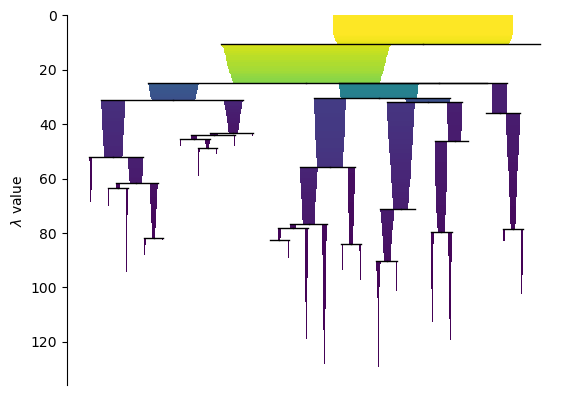

In [37]:
split_ct = condense_tree_split(l2, mst[:, 2], min_cluster_size=min_cluster_size)
equal_trees(current_ct, split_ct)
PlotTree(to_numpy_rec_array(split_ct), np.zeros(data.shape[0])).plot(
    colorbar=False, leaf_separation=0.1
)
plt.show()

In [38]:
%%timeit 
condense_tree_split(l2, mst[:, 2], min_cluster_size=min_cluster_size)

83.7 µs ± 312 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Combined

The new version is about 2x faster mainly by avoiding allocations in the BF traversal.

In [31]:
%%timeit
linkage = current_mst_to_linkage_tree(mst)
condensed = current_condense_tree(linkage, min_cluster_size=min_cluster_size)

91.7 µs ± 1.14 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [32]:
%%timeit
l2 = mst_to_linkage_tree(mst)
condensed = condense_tree(l2, mst[:, 2], min_cluster_size=min_cluster_size)

43.5 µs ± 679 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
